In [1]:
# =============================================================================
# Loads the 8 synthetic nodes generated in 01_block_bootstrap_node_expansion
# and applies two individualization techniques:
#   1. Bias-Offset:       simulates hardware differences between physical EVSE units
#   2. Timestamp-Jitter:  simulates network latency differences between nodes
# =============================================================================

import pandas as pd
import numpy as np
import os

# --- Configuration ---
INPUT_DIR  = '../datasets/CICEVSE2024/synthetic_nodes/01_node_expansion/'
OUTPUT_DIR = '../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SYNTHETIC_NODES = 8
SENSOR_COLS       = ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW']
BIAS_STD          = 0.01    # 1% std relative to each feature's mean
JITTER_MS_STD     = 500     # network jitter std in milliseconds

In [2]:
# --- Load synthetic nodes ---
synthetic_nodes = {}
for i in range(1, N_SYNTHETIC_NODES + 1):
    path = INPUT_DIR + f'node_synthetic_{i}.csv'
    df = pd.read_csv(path)
    df['time'] = pd.to_datetime(df['time'])
    synthetic_nodes[f'synthetic_{i}'] = df
    print(f"Loaded: node_synthetic_{i}.csv  ({len(df):,} rows)")

Loaded: node_synthetic_1.csv  (115,358 rows)
Loaded: node_synthetic_2.csv  (115,286 rows)
Loaded: node_synthetic_3.csv  (115,490 rows)
Loaded: node_synthetic_4.csv  (114,802 rows)
Loaded: node_synthetic_5.csv  (115,025 rows)
Loaded: node_synthetic_6.csv  (115,339 rows)
Loaded: node_synthetic_7.csv  (115,462 rows)
Loaded: node_synthetic_8.csv  (115,048 rows)


In [3]:
df_power = pd.read_csv('../datasets/CICEVSE2024/Power Consumption/EVSE-B-PowerCombined.csv')
df_power['time'] = pd.to_datetime(df_power['time'])

print("Shape:", df_power.shape)
print("Columns:", df_power.columns.tolist())

Shape: (115298, 10)
Columns: ['time', 'shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'State', 'Attack', 'Attack-Group', 'Label', 'interface']


Correlation Matrix — Full Dataset (n=115,298)
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage          1.000         -0.955       0.935     0.927
bus_voltage_V         -0.955          1.000      -0.948    -0.941
current_mA             0.935         -0.948       1.000     0.964
power_mW               0.927         -0.941       0.964     1.000

Correlation Matrix — Benign only (n=14,363)
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage          1.000         -0.735       0.610     0.542
bus_voltage_V         -0.735          1.000      -0.682    -0.640
current_mA             0.610         -0.682       1.000     0.781
power_mW               0.542         -0.640       0.781     1.000

Correlation Matrix — Attack only (n=100,935)
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage          1.000         -0.962       0.945     0.938
bus_voltage_V         -0.962          1.000      -0.955    -0.949
curre

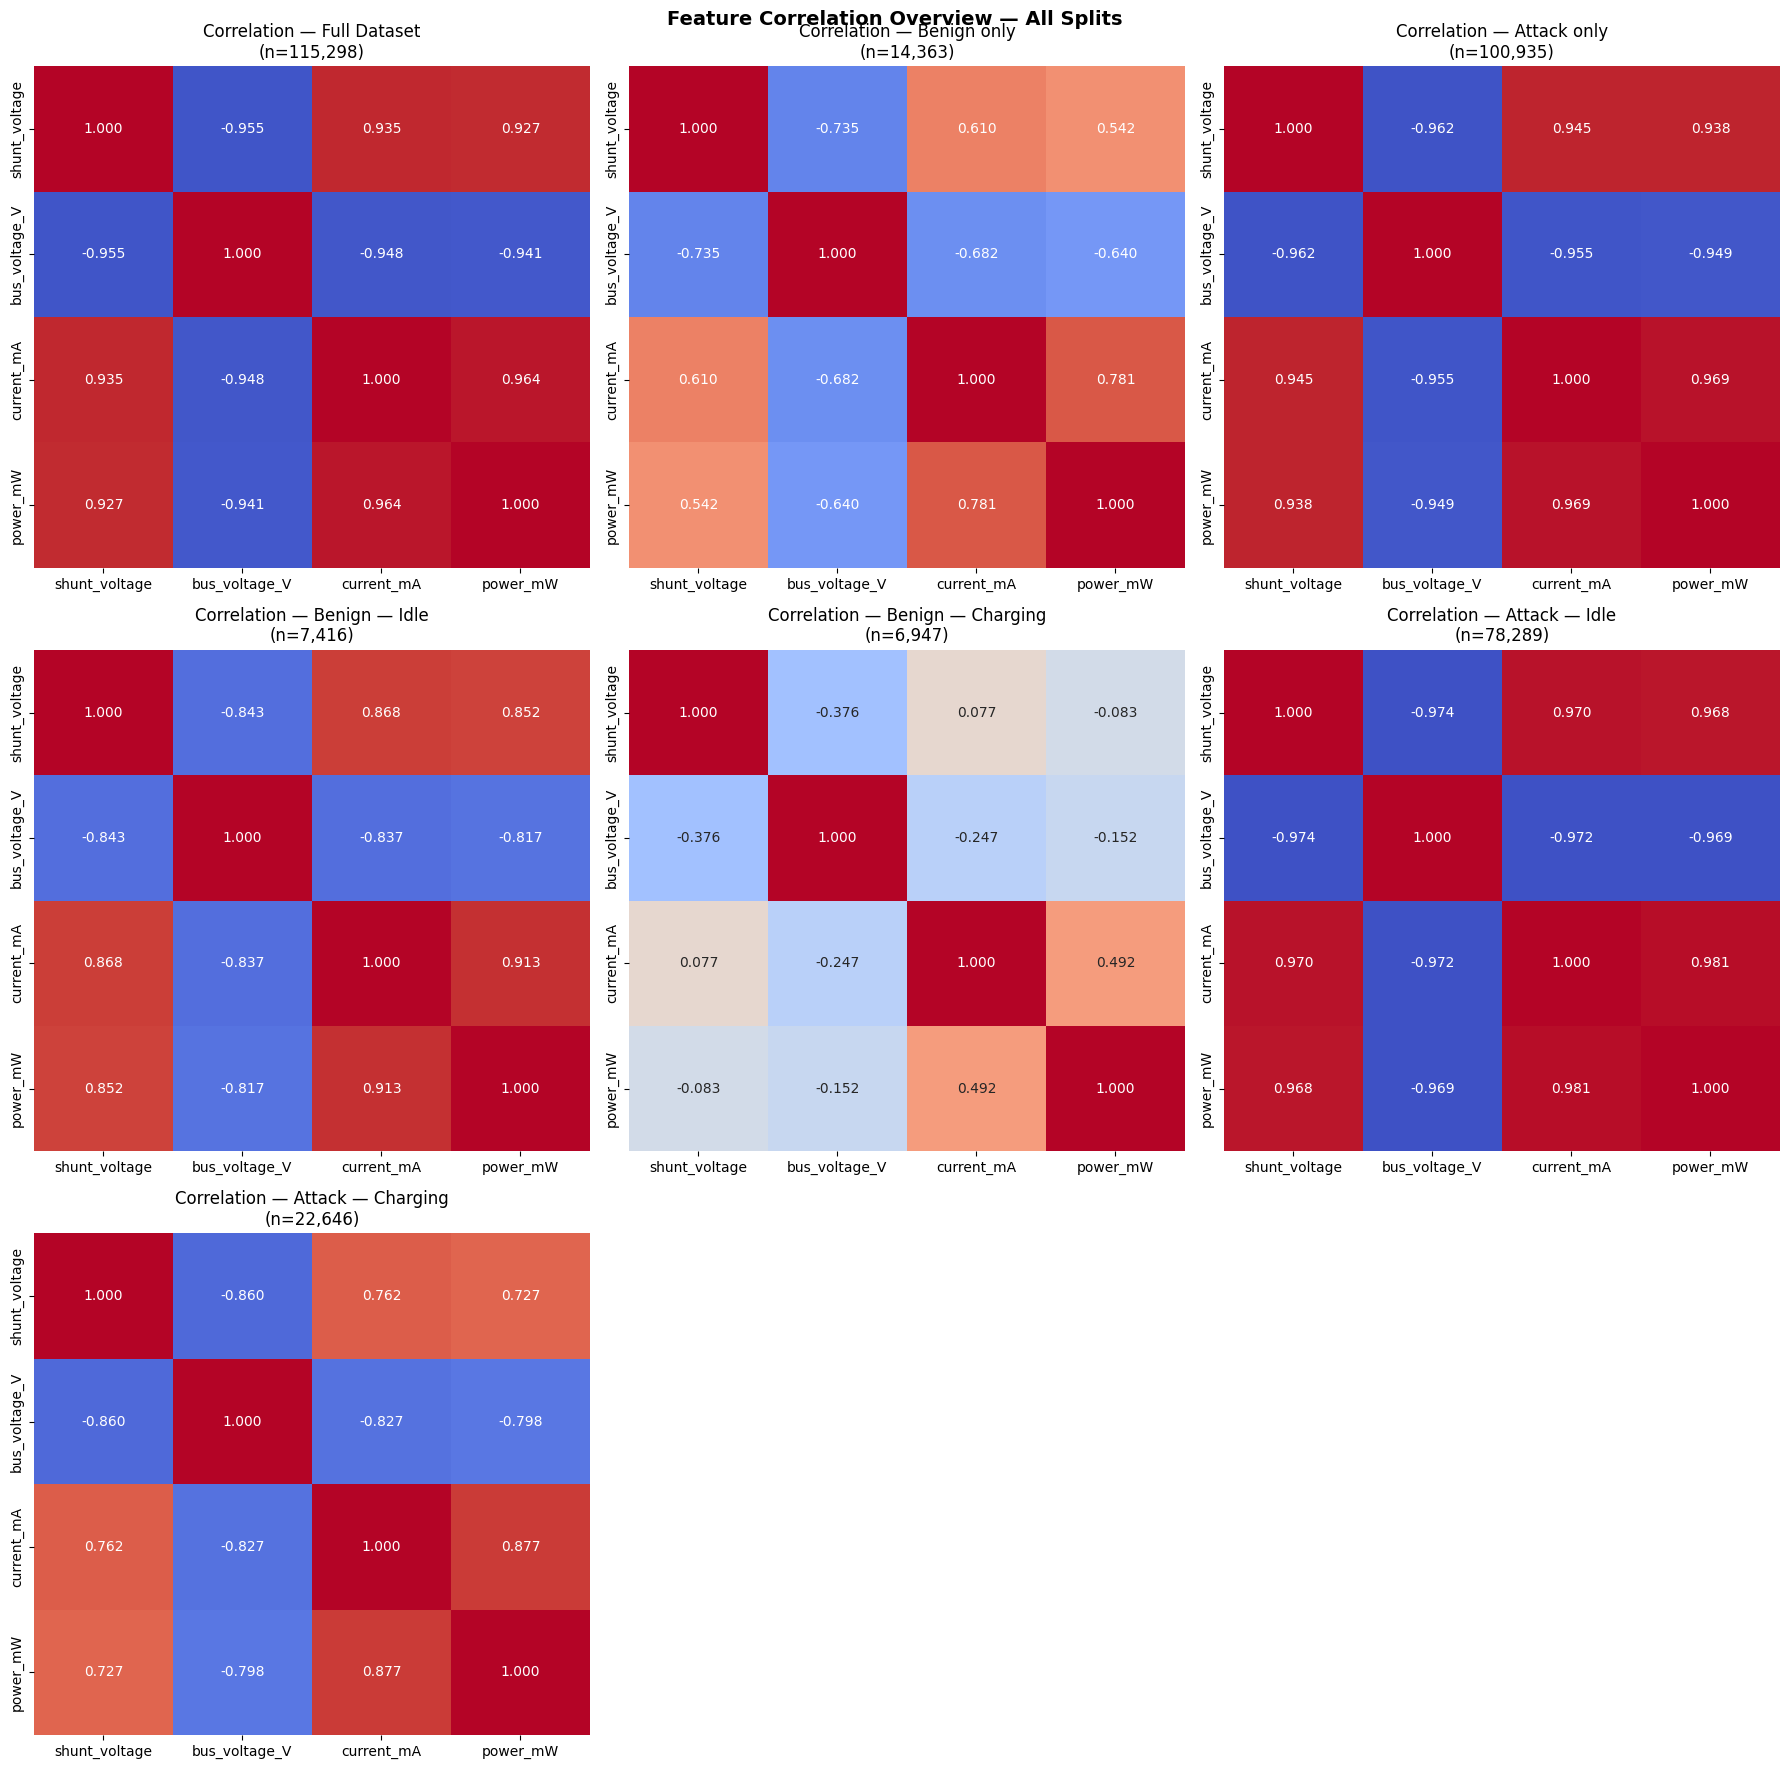

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

subsets = [
    ('Full Dataset',         df_power),
    ('Benign only',          df_power[df_power['Label'] == 'benign']),
    ('Attack only',          df_power[df_power['Label'] == 'attack']),
    ('Benign — Idle',        df_power[(df_power['Label'] == 'benign') & (df_power['State'] == 'idle')]),
    ('Benign — Charging',    df_power[(df_power['Label'] == 'benign') & (df_power['State'] == 'charging')]),
    ('Attack — Idle',        df_power[(df_power['Label'] == 'attack') & (df_power['State'] == 'idle')]),
    ('Attack — Charging',    df_power[(df_power['Label'] == 'attack') & (df_power['State'] == 'charging')]),
]

n_plots = len(subsets)
n_cols  = 3
n_rows  = (n_plots + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, (label, subset) in enumerate(subsets):
    corr = subset[SENSOR_COLS].corr()
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
                vmin=-1, vmax=1, ax=axes[i], cbar=False)
    axes[i].set_title(f'Correlation — {label}\n(n={len(subset):,})')

    print("=" * 55)
    print(f"Correlation Matrix — {label} (n={len(subset):,})")
    print("=" * 55)
    print(corr.round(3).to_string())
    print()

# Hide unused subplots
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Correlation Overview — All Splits',
             fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('../datasets/CICEVSE2024/synthetic_nodes/correlation_matrix_full.png',
#            dpi=150, bbox_inches='tight')
plt.show()

In [5]:
txt = '''
## Justification: State-Specific BIAS_STD from Benign Data Only

The Bias-Offset models sensor calibration variance between physical EVSE units.
It is derived from benign data only, since attack data reflects manipulated signals
rather than hardware characteristics.

A state-specific derivation is necessary because idle and charging show fundamentally
different sensor dynamics:
- **Benign Idle**: sensors near-zero, tightly coupled (r = 0.85–0.91) → small variance
- **Benign Charging**: active load, sensors largely independent (r = -0.08–0.49) → larger variance

A single global BIAS_STD would conflate these two regimes and produce physically
implausible synthetic nodes. Each synthetic node therefore receives one fixed offset
per feature per state, drawn from Normal(0, BIAS_STD_state_feature).
'''
print(txt)


## Justification: State-Specific BIAS_STD from Benign Data Only

The Bias-Offset models sensor calibration variance between physical EVSE units.
It is derived from benign data only, since attack data reflects manipulated signals
rather than hardware characteristics.

A state-specific derivation is necessary because idle and charging show fundamentally
different sensor dynamics:
- **Benign Idle**: sensors near-zero, tightly coupled (r = 0.85–0.91) → small variance
- **Benign Charging**: active load, sensors largely independent (r = -0.08–0.49) → larger variance

A single global BIAS_STD would conflate these two regimes and produce physically
implausible synthetic nodes. Each synthetic node therefore receives one fixed offset
per feature per state, drawn from Normal(0, BIAS_STD_state_feature).



In [6]:
benign_df = df_power[df_power['Label'] == 'benign']

bias_std_config = {}

print(f"{'State':<12} {'Feature':<15} {'Mean':>10} {'Std':>10} {'Std/Mean%':>12}")
print("-" * 60)

for state, state_df in benign_df.groupby('State'):
    bias_std_config[state] = {}
    for col in SENSOR_COLS:
        mean = state_df[col].mean()
        std  = state_df[col].std()
        rel  = (std / abs(mean)) * 100 if mean != 0 else float('nan')
        bias_std_config[state][col] = std
        print(f"{state:<12} {col:<15} {mean:>10.4f} {std:>10.4f} {rel:>11.2f}%")
    print()

print("-> bias_std_config ready for individualization")

State        Feature               Mean        Std    Std/Mean%
------------------------------------------------------------
charging     shunt_voltage     609.5247    90.5479       14.86%
charging     bus_voltage_V       5.1902     0.0062        0.12%
charging     current_mA        607.0508    90.5172       14.91%
charging     power_mW         3154.3688   471.3690       14.94%

idle         shunt_voltage     474.5518    52.6222       11.09%
idle         bus_voltage_V       5.1998     0.0041        0.08%
idle         current_mA        474.3530    52.4890       11.07%
idle         power_mW         2468.7999   274.5959       11.12%

-> bias_std_config ready for individualization


In [7]:
INPUT_DIR  = '../datasets/CICEVSE2024/synthetic_nodes/01_node_expansion/'
OUTPUT_DIR = '../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SENSOR_COLS       = ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW']
N_SYNTHETIC_NODES = 8
JITTER_MS_STD     = 500  # network latency std in milliseconds

# Empirically derived from benign data per state (see 02_correlation_analysis)
bias_std_config = {
    'charging': {
        'shunt_voltage' :  90.5479,
        'bus_voltage_V' :   0.0062,
        'current_mA'    :  90.5172,
        'power_mW'      : 471.3690,
    },
    'idle': {
        'shunt_voltage' :  52.6222,
        'bus_voltage_V' :   0.0041,
        'current_mA'    :  52.4890,
        'power_mW'      : 274.5959,
    }
}

In [8]:
# --- Load synthetic nodes ---
synthetic_nodes = {}
for i in range(1, N_SYNTHETIC_NODES + 1):
    path = INPUT_DIR + f'node_synthetic_{i}.csv'
    df = pd.read_csv(path)
    df['time'] = pd.to_datetime(df['time'])
    # Cast sensor columns to float to allow bias offset addition
    df[SENSOR_COLS] = df[SENSOR_COLS].astype(float)
    synthetic_nodes[f'synthetic_{i}'] = df
    print(f"Loaded: node_synthetic_{i}.csv  ({len(df):,} rows)")

Loaded: node_synthetic_1.csv  (115,358 rows)
Loaded: node_synthetic_2.csv  (115,286 rows)
Loaded: node_synthetic_3.csv  (115,490 rows)
Loaded: node_synthetic_4.csv  (114,802 rows)
Loaded: node_synthetic_5.csv  (115,025 rows)
Loaded: node_synthetic_6.csv  (115,339 rows)
Loaded: node_synthetic_7.csv  (115,462 rows)
Loaded: node_synthetic_8.csv  (115,048 rows)


In [9]:
# --- Individualization function ---
def individualize_node(node_df: pd.DataFrame, seed: int) -> tuple:
    rng = np.random.default_rng(seed)
    df  = node_df.copy()

    # 1. Bias-Offset: one fixed offset per feature per state, drawn once per node.
    #    Models systematic hardware differences (sensor calibration variance).
    #    Derived from benign state-specific std — see correlation analysis notebook.
    applied_biases = {}
    for state, state_std in bias_std_config.items():
        mask = df['State'] == state
        if mask.sum() == 0:
            continue
        applied_biases[state] = {}
        for col, std in state_std.items():
            bias = rng.normal(loc=0.0, scale=std)
            df.loc[mask, col] = df.loc[mask, col] + bias
            applied_biases[state][col] = round(bias, 4)

    # 2. Timestamp-Jitter: one fixed time offset per node.
    #    Models constant network latency differences between nodes.
    jitter_ms = int(rng.normal(loc=0.0, scale=JITTER_MS_STD))
    df['time'] = df['time'] + pd.Timedelta(milliseconds=jitter_ms)

    return df, jitter_ms, applied_biases

In [10]:
# --- Apply individualization ---
individualized_nodes = {}
metadata = []

for i, (name, node_df) in enumerate(synthetic_nodes.items()):
    ind_df, jitter_ms, biases = individualize_node(node_df, seed=200 + i)
    individualized_nodes[name] = ind_df
    metadata.append({
        'node'      : name,
        'seed'      : 200 + i,
        'jitter_ms' : jitter_ms,
        **{f'bias_{state}_{col}': biases.get(state, {}).get(col, None)
           for state in bias_std_config
           for col in SENSOR_COLS}
    })

print(f"Individualization applied to {len(individualized_nodes)} nodes.")

Individualization applied to 8 nodes.


In [11]:
# --- Verification ---
df_real = pd.read_csv(INPUT_DIR + 'node_real_EVSE-B.csv')

print("=" * 75)
print("NODE INDIVIDUALIZATION — VERIFICATION")
print("=" * 75)
print(f"{'Node':<15} {'State':<12}", end="")
for col in SENSOR_COLS:
    print(f"  {col[:10]:<12}", end="")
print(f"  {'jitter_ms':>10}")
print("-" * 75)

for state in ['idle', 'charging']:
    ref = df_real[df_real['State'] == state]
    print(f"{'EVSE-B (real)':<15} {state:<12}", end="")
    for col in SENSOR_COLS:
        print(f"  {ref[col].mean():<12.2f}", end="")
    print(f"  {'0':>10}")

print("-" * 75)

for meta in metadata:
    name = meta['node']
    for state in ['idle', 'charging']:
        subset = individualized_nodes[name]
        subset = subset[subset['State'] == state]
        print(f"{name:<15} {state:<12}", end="")
        for col in SENSOR_COLS:
            print(f"  {subset[col].mean():<12.2f}", end="")
        jitter = meta['jitter_ms'] if state == 'idle' else ''
        print(f"  {str(jitter):>10}")

print("=" * 75)

NODE INDIVIDUALIZATION — VERIFICATION
Node            State         shunt_volt    bus_voltag    current_mA    power_mW       jitter_ms
---------------------------------------------------------------------------
EVSE-B (real)   idle          577.58        5.19          577.53        2996.71                0
EVSE-B (real)   charging      742.03        5.18          742.07        3838.57                0
---------------------------------------------------------------------------
synthetic_1     idle          625.92        5.19          557.37        2562.47             -388
synthetic_1     charging      781.55        5.18          708.09        4029.02                 
synthetic_2     idle          667.09        5.19          561.61        3043.15              155
synthetic_2     charging      903.53        5.18          541.19        3394.26                 
synthetic_3     idle          510.73        5.20          617.73        3141.18              704
synthetic_3     charging      910.

In [14]:
# --- Save ---

# Save real node as reference baseline (no individualization applied)
df_real = pd.read_csv(INPUT_DIR + 'node_real_EVSE-B.csv')
df_real[SENSOR_COLS] = df_real[SENSOR_COLS].astype(float)
df_real.to_csv(OUTPUT_DIR + 'node_real_EVSE-B.csv', index=False)
print(f"Saved: {OUTPUT_DIR}node_real_EVSE-B.csv  ({len(df_real):,} rows)")

# Save individualized synthetic nodes
for name, node_df in individualized_nodes.items():
    path = OUTPUT_DIR + f'node_{name}_individualized.csv'
    node_df.to_csv(path, index=False)
    print(f"Saved: {path}  ({len(node_df):,} rows)")

pd.DataFrame(metadata).to_csv(OUTPUT_DIR + 'individualization_metadata.csv', index=False)
print(f"\nMetadata saved.")
print(f"Done. {N_SYNTHETIC_NODES + 1} nodes saved to: {OUTPUT_DIR}")

Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_real_EVSE-B.csv  (115,298 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_1_individualized.csv  (115,358 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_2_individualized.csv  (115,286 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_3_individualized.csv  (115,490 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_4_individualized.csv  (114,802 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_5_individualized.csv  (115,025 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_6_individualized.csv  (115,339 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/02_individualized_nodes/node_synthetic_7_individualized.csv  (115,462 rows)
Saved: ../datasets/CICEVSE2024/

In [15]:
txt = '''
## Verification Analysis — Node Individualization

### bus_voltage_V — Nearly identical across all nodes (5.17–5.20V)
Expected. The benign std for bus_voltage_V was tiny (0.004–0.006V),
so the bias offset is negligible. Bus voltage is regulated by the
charger hardware and does not vary significantly between units.

### shunt_voltage & current_mA — Shifted per node, asymmetrically
Each node shows a different mean, shifted from EVSE-B (real):
- idle:     EVSE-B = 577 mA,  synthetic range = 510–667 mA  (±~90 mA, matches idle std=52)
- charging: EVSE-B = 742 mA,  synthetic range = 700–910 mA  (±~90 mA, matches charging std=90)

Note: shunt_voltage and current_mA are shifted **independently** per node,
which is correct — the weak charging correlation (0.077) justifies independent offsets.

### power_mW — Largest absolute spread
- idle:     EVSE-B = 2997 mW, synthetic range = 2505–3222 mW  (matches idle std=274)
- charging: EVSE-B = 3839 mW, synthetic range = 3394–4641 mW  (matches charging std=471)

The spread is proportional to the empirically derived std values — working as intended.

### Timestamp-Jitter — Plausible network latency offsets
Range: -964ms to +704ms, std ≈ 500ms as configured.
All values are well within the MAXTIMESKEWSECONDS = 90s filter threshold,
so no synthetic node will be accidentally excluded by the time-skew filter.

### One issue: shunt_voltage and current_mA diverge strongly per node
Example — synthetic_2 charging: shunt=903mA vs current=541mA (Δ=362mA)
In reality these two are physically coupled (shunt measures current).
This divergence is an artifact of applying independent biases to correlated features.
-> Acceptable for this study as a synthetic approximation, but should be
   documented as a known limitation of the intra-node bootstrap approach.
'''

print(txt)


## Verification Analysis — Node Individualization

### bus_voltage_V — Nearly identical across all nodes (5.17–5.20V)
Expected. The benign std for bus_voltage_V was tiny (0.004–0.006V),
so the bias offset is negligible. Bus voltage is regulated by the
charger hardware and does not vary significantly between units.

### shunt_voltage & current_mA — Shifted per node, asymmetrically
Each node shows a different mean, shifted from EVSE-B (real):
- idle:     EVSE-B = 577 mA,  synthetic range = 510–667 mA  (±~90 mA, matches idle std=52)
- charging: EVSE-B = 742 mA,  synthetic range = 700–910 mA  (±~90 mA, matches charging std=90)

Note: shunt_voltage and current_mA are shifted **independently** per node,
which is correct — the weak charging correlation (0.077) justifies independent offsets.

### power_mW — Largest absolute spread
- idle:     EVSE-B = 2997 mW, synthetic range = 2505–3222 mW  (matches idle std=274)
- charging: EVSE-B = 3839 mW, synthetic range = 3394–4641 mW  (matches charging

In [19]:
txt = '''## ✅ Part 2 Complete — Node Individualization

### Bias-Offset
- Derived empirically from benign data per state (idle / charging)
- One fixed offset per feature per state, drawn once per node from Normal(0, std)
- Models realistic sensor calibration variance between physical EVSE units
- bus_voltage_V intentionally minimal (std = 0.004–0.006V → hardware-regulated)
- Known limitation: independent offsets on physically coupled features
  (shunt_voltage ↔ current_mA) → documented as synthetic approximation

### Timestamp-Jitter
- One fixed time offset per node drawn from Normal(0, 500ms)
- Models constant network latency differences between nodes
- All jitter values within ±1500ms

| Parameter         | Value                                  |
|-------------------|----------------------------------------|
| bias_std source   | Benign only, state-specific            |
| idle std range    | 0.004 – 274.6 (per feature)            |
| charging std range| 0.006 – 471.4 (per feature)            |
| jitter std        | 500ms                                  |
| Output            | ../datasets/CICEVSE2024/individualized_nodes/ |

**Next:** Part 3 — Label-Shift (Echo-Chamber sweep, 03_label_shift.ipynb)'''

print(txt)

## ✅ Part 2 Complete — Node Individualization

### Bias-Offset
- Derived empirically from benign data per state (idle / charging)
- One fixed offset per feature per state, drawn once per node from Normal(0, std)
- Models realistic sensor calibration variance between physical EVSE units
- bus_voltage_V intentionally minimal (std = 0.004–0.006V → hardware-regulated)
- Known limitation: independent offsets on physically coupled features
  (shunt_voltage ↔ current_mA) → documented as synthetic approximation

### Timestamp-Jitter
- One fixed time offset per node drawn from Normal(0, 500ms)
- Models constant network latency differences between nodes
- All jitter values within ±1500ms

| Parameter         | Value                                  |
|-------------------|----------------------------------------|
| bias_std source   | Benign only, state-specific            |
| idle std range    | 0.004 – 274.6 (per feature)            |
| charging std range| 0.006 – 471.4 (per feature)           